In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append("../backend")

In [3]:
import torch as t
import torch.nn as nn
device = "cuda" if t.cuda.is_available() else "mps" if t.backends.mps.is_available() else "cpu"
device

'cuda'

In [4]:
import pandas as pd
import torch as t
import torch.nn as nn
import torch.optim as optim
import numpy as np
from cuml.manifold.umap import UMAP
from cuml import TSNE

/home/bkantz/cgv/other/highdim-gradex/.venv/lib/python3.13/site-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


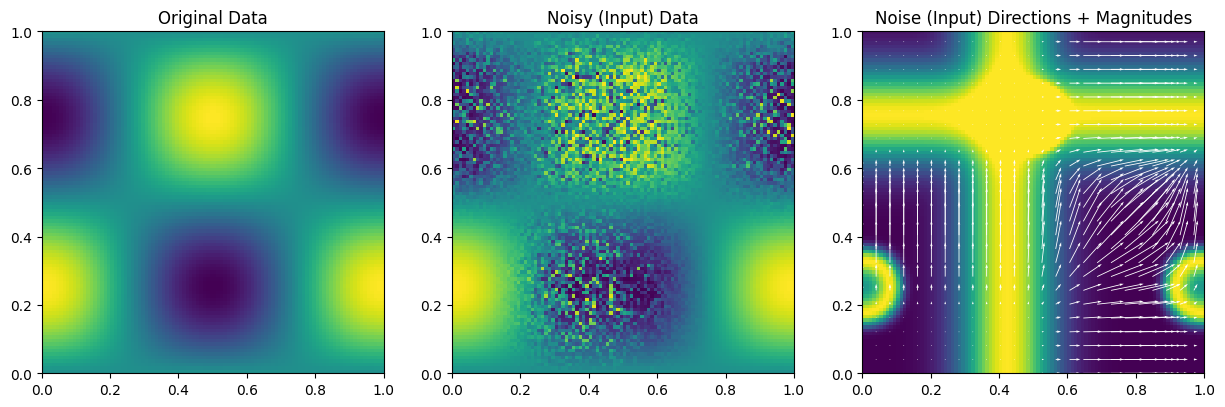

In [5]:
from seaborn import cm
from noise import ColumnBasedNoiser, SingleModeColumnNoiser, SingleModeGlobalNoiser
import matplotlib.pyplot as plt

test_x1 = t.linspace(0, 1, 100)
test_x2 = t.linspace(0, 1, 100)
test_X = t.stack(t.meshgrid(test_x1, test_x2), dim=-1).reshape(-1, 2)


def test_f(x):
    return t.sin(x[:, 0] * 2 * t.pi) * t.cos(x[:, 1] * 2 * t.pi)


test_y = test_f(test_X)

test_full = t.stack([test_X[:, 0], test_X[:, 1], test_y], dim=-1)

test_noiser = SingleModeGlobalNoiser(noise_level=0.2, seed=42)
test_noisy, noise_levels = test_noiser.add_noise(test_full)


plts, axs = plt.subplots(1, 3, figsize=(15, 5))

axs[0].imshow(
    test_y.reshape(100, 100).cpu(), extent=(0, 1, 0, 1), origin="lower", cmap="viridis"
)
axs[0].set_title("Original Data")

axs[1].imshow(
    test_f(test_noisy[:, :2]).reshape(100, 100).cpu(),
    extent=(0, 1, 0, 1),
    origin="lower",
    cmap="viridis",
)
axs[1].set_title("Noisy (Input) Data")

noise_levels_r = noise_levels.reshape(100, 100, -1)
noise_levels_magnitude = t.linalg.norm(noise_levels_r, dim=-1)
axs[2].imshow(
    noise_levels_magnitude.cpu(),
    extent=(0, 1, 0, 1),
    origin="lower",
    cmap="viridis",
    vmin=0,
    vmax=1,
)
subsampling = 4
axs[2].quiver(
    test_X.reshape(100, 100, 2)[::subsampling, ::subsampling, 0].cpu(),
    test_X.reshape(100, 100, 2)[::subsampling, ::subsampling, 1].cpu(),
    noise_levels_r[::subsampling, ::subsampling, 0].cpu(),
    noise_levels_r[::subsampling, ::subsampling, 1].cpu(),
    color="white",
    scale=10,
)

axs[2].set_title("Noise (Input) Directions + Magnitudes")

plt.show()

In [6]:
import noise
import models

In [7]:
import torch.utils.data as data_utils
from tqdm import tqdm


In [8]:
from torchmetrics.functional import r2_score

from models.base import BaseUCQModel


# from https://hunterheidenreich.com/posts/modern-variational-autoencoder-in-pytorch/
def train_vae(
    cleaned: pd.DataFrame,
    vae_model=models.VAE,
    noise_model: noise.Noiser = None,
    val_percent: float = 0.2,
    test_percent: float = 0.1,
    lr: float = 1e-3,
    epochs: int = 3,
    batch_size: int = 128,
    log=False,
    model_kwargs={},
):
    diff = cleaned.max() - cleaned.min()
    diff[diff == 0] = cleaned.max()[diff == 0]
    diff[diff == 0] = 1
    data_normed = (cleaned - cleaned.min()) / diff
    data_t = t.tensor(data_normed.values, dtype=t.float32)
    noise_t = t.zeros_like(data_t)
    if noise_model is not None:
        data_t, noise_t = noise_model.add_noise(data_t)
        if log:
            print("Added noise with model:", noise_model.__class__.__name__)

    dataset = data_utils.TensorDataset(data_t, noise_t)

    val_size = int(len(dataset) * val_percent)
    test_size = int(len(dataset) * test_percent)
    train_size = len(dataset) - val_size - test_size
    train_dataset, val_dataset, test_dataset = data_utils.random_split(
        dataset, [train_size, val_size, test_size]
    )

    train_dataloader = data_utils.DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True
    )
    val_dataloader = data_utils.DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    model: BaseUCQModel = vae_model(
        input_size=data_t.shape[1],
        **model_kwargs,
    ).to(device)
    model.fit(train_dataloader, epochs=epochs, val_dataloader=val_dataloader, log=log, lr=lr)
    model.eval()
    return {
        "base_data": data_t,
        "noise_data": noise_t,
        "vae_model": model,
        "training": {
            "data": train_dataset[:][0],
            "noise": train_dataset[:][1],
        },
        "validation": {
            "data": val_dataset[:][0],
            "noise": val_dataset[:][1],
        },
        "test": {
            "data": test_dataset[:][0],
            "noise": test_dataset[:][1],
        },
    }


# train_vae(cleaned)

In [9]:
test_data_df = pd.DataFrame(
    test_full.cpu().numpy(), columns=["x1", "x2", "y"]
)
test_data_df

,x1,x2,y
0,0.0,0.000000,0.000000e+00
1,0.0,0.010101,0.000000e+00
2,0.0,0.020202,0.000000e+00
3,0.0,0.030303,0.000000e+00
4,0.0,0.040404,0.000000e+00
...,...,...,...
9995,1.0,0.959596,1.692415e-07
9996,1.0,0.969697,1.716859e-07
9997,1.0,0.979798,1.734389e-07
9998,1.0,0.989899,1.744935e-07


In [10]:
results = train_vae(
    test_data_df,  # cleanded[[input_cols + output_cols]]
    vae_model=models.VAE,
    noise_model=noise.ColumnBasedNoiser(noise_level=0.2),
    epochs=10,
    batch_size=128,
    model_kwargs={
        "layers": [64],
        "latent_size": 8,
        "norm": nn.BatchNorm1d,
        "out_norm": nn.BatchNorm1d,
    },
    log=True,
)

Added noise with model: ColumnBasedNoiser


  0%|          | 0/550 [00:00<?, ?it/s]

Epoch 1/10, Train Loss: -2.5714
           Val Loss: -2.6600, Val R2 Score: -6.5863
Epoch 2/10, Train Loss: -3.0867
           Val Loss: -3.1946, Val R2 Score: -4.8224
Epoch 3/10, Train Loss: -3.7685
           Val Loss: -3.7807, Val R2 Score: -3.3609
Epoch 4/10, Train Loss: -4.8770
           Val Loss: -4.7168, Val R2 Score: -2.1302
Epoch 5/10, Train Loss: -5.6778
           Val Loss: -6.1756, Val R2 Score: -1.0759
Epoch 6/10, Train Loss: -7.1575
           Val Loss: -7.2834, Val R2 Score: -0.2105
Epoch 7/10, Train Loss: -8.2150
           Val Loss: -8.4173, Val R2 Score: 0.4447
Epoch 8/10, Train Loss: -10.8898
           Val Loss: -10.8588, Val R2 Score: 0.8535
Epoch 9/10, Train Loss: -11.9529
           Val Loss: -12.7352, Val R2 Score: 0.9356
Epoch 10/10, Train Loss: -13.3702
           Val Loss: -13.8568, Val R2 Score: 0.9477


In [11]:
results_bgplvm = train_vae(
    test_data_df,  # cleanded[[input_cols + output_cols]]
    vae_model=models.GP_VAE,
    noise_model=noise.ColumnBasedNoiser(noise_level=0.2),
    epochs=50,
    batch_size=128,
    log=True,
    lr=0.001,
    model_kwargs={"retrain_vae": False, "vae_model": results["vae_model"], "latent_size": 8},
)

Added noise with model: ColumnBasedNoiser
Initializing MultitaskGP with input size 8 and latent size 4 and n_inducing 512
Inducing points shape: torch.Size([4, 512, 8])


  0%|          | 0/2750 [00:00<?, ?it/s]

In [12]:
from models import GP_VAE


gp_vae: GP_VAE = results_bgplvm["vae_model"]
X = results_bgplvm["validation"]["data"].to(device)
encoded = gp_vae.vae_model.encode(X)
dist = gp_vae.likelihood(gp_vae.gp(encoded[1]))

In [35]:
dist.variance

tensor([[0.0797, 0.0839, 0.1357],
        [0.0796, 0.0839, 0.1356],
        [0.0799, 0.0840, 0.1359],
        ...,
        [0.0802, 0.0844, 0.1369],
        [0.0813, 0.0856, 0.1395],
        [0.0796, 0.0838, 0.1357]], device='cuda:0', grad_fn=<ViewBackward0>)

In [23]:
results_bgplvm["validation"]["noise"]

tensor([[0.2000, 0.0765, 0.1393],
        [0.2000, 0.0765, 0.1393],
        [0.2000, 0.0765, 0.1393],
        ...,
        [0.2000, 0.0765, 0.1393],
        [0.2000, 0.0765, 0.1393],
        [0.2000, 0.0765, 0.1393]])

In [14]:
result_random = train_vae(
    test_data_df,  # cleanded[[input_cols + output_cols]]
    vae_model=models.RandomBaseline,
    noise_model=noise.ColumnBasedNoiser(noise_level=0.2),
    epochs=10,
    log=True,
)

Added noise with model: ColumnBasedNoiser


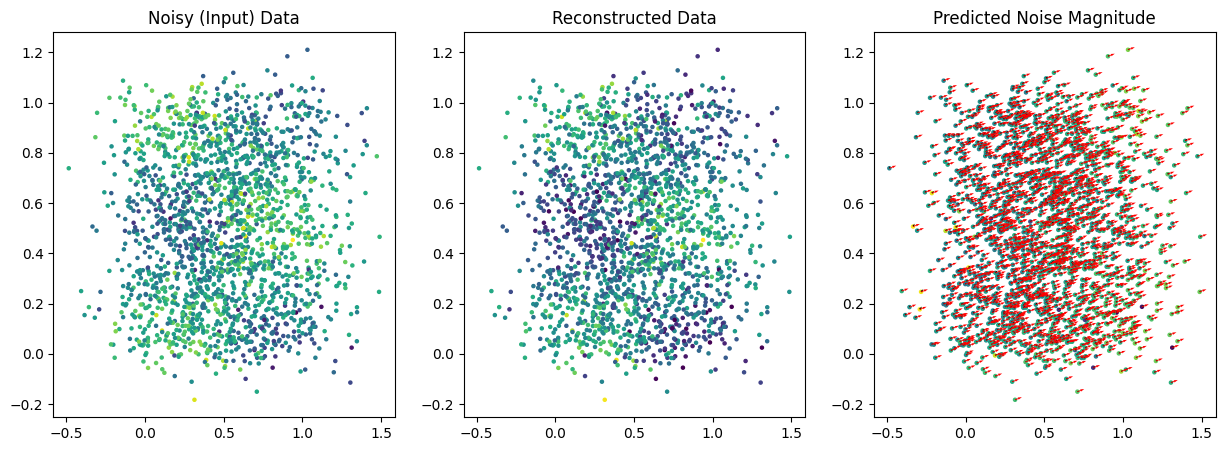

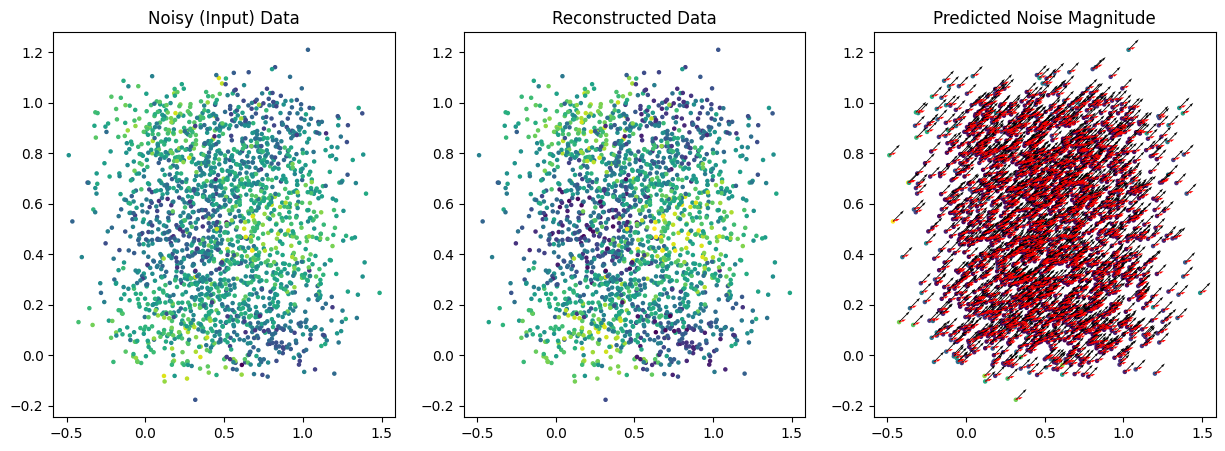

In [31]:
def plot_results(results, title="VAE Results"):
    model: BaseUCQModel = results["vae_model"]
    X = results["validation"]["data"].to(device)
    noise = results["validation"]["noise"]
    with t.no_grad():
        reconstructed = model(X)
        if isinstance(reconstructed, tuple):
            reconstructed = reconstructed[0]  
        elif isinstance(model, models.GP_VAE):  
            reconstructed = reconstructed.mean        
        predicted_noise = model.uncertainty(X)
    reconstructed = reconstructed.cpu()
    X = X.cpu()
    predicted_noise = predicted_noise.cpu()
    noise = noise.cpu()
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))

    axs[0].scatter(
        X[:, 0], X[:, 1], c=(X[:, 2]).cpu(), cmap="viridis", s=5
    )
    axs[0].set_title("Noisy (Input) Data")

    axs[1].scatter(
        X[:, 0], X[:, 1], c=(reconstructed[:, 2]).cpu(), cmap="viridis", s=5
    )
    axs[1].set_title("Reconstructed Data")

    axs[2].scatter(
        X[:, 0],
        X[:, 1],
        c=predicted_noise[:, 2].cpu(),
        cmap="viridis",
        s=5,
    )
    axs[2].set_title("Predicted Noise Magnitude")

    axs[2].quiver(
        X[:, 0],
        X[:, 1],
        predicted_noise[:, 0],
        predicted_noise[:, 1],
        color="black",
        scale=10,
    )
    axs[2].quiver(
        X[:, 0],
        X[:, 1],
        noise[:, 0],
        noise[:, 1],
        color="red",
        scale=10,
    )
    axs[2].set_title("Predicted Noise Magnitude")


plot_results(results, title="VAE Results")
plot_results(results_bgplvm, title="GP-VAE Results")

In [32]:
from torchmetrics.functional import f1_score, r2_score
from torchmetrics.functional.retrieval import (
    retrieval_normalized_dcg,
    retrieval_precision,
    retrieval_recall,
)
from torchmetrics.retrieval import recall

import models.base

top_k = 5


def noise_metric_r2_normed(noise: t.Tensor, predicted_noise: t.Tensor) -> float:
    noise_normed = noise / noise.max(dim=1).values[:, None]
    predicted_noise_normed = (
        predicted_noise / predicted_noise.max(dim=1).values[:, None]
    )
    return (
        r2_score(predicted_noise_normed, noise_normed, multioutput="raw_values")
        .mean()
        .item()
    )


def noise_metric_r2(noise: t.Tensor, predicted_noise: t.Tensor) -> float:
    return r2_score(predicted_noise, noise, multioutput="raw_values").mean().item()


def noise_metric_ndcg_k(
    noise: t.Tensor, predicted_noise: t.Tensor, k: int = top_k
) -> float:
    from torchmetrics.retrieval import RetrievalNormalizedDCG as NDCG

    max_noises_target = t.argsort(noise, descending=True, dim=1)
    probs_noises_target = max_noises_target.float() / float(noise.shape[-1])
    max_noises_predicted = t.argsort(predicted_noise, descending=True, dim=1)
    probs_noises_predicted = max_noises_predicted.float() / float(noise.shape[-1])

    return (
        retrieval_normalized_dcg(probs_noises_target, probs_noises_predicted, top_k=k)
        .mean()
        .item()
    )


def noise_metric_f1_k(
    noise: t.Tensor, predicted_noise: t.Tensor, k: int = top_k
) -> float:
    max_noises_target = t.argsort(noise, descending=True, dim=1)
    probs_noises_target = max_noises_target.float() / float(noise.shape[-1])
    max_noises_predicted = t.argsort(predicted_noise, descending=True, dim=1)
    probs_noises_predicted = max_noises_predicted.float() / float(noise.shape[-1])
    precision = retrieval_precision(
        probs_noises_predicted, probs_noises_target, top_k=k
    )
    recall_score = retrieval_recall(
        probs_noises_predicted, probs_noises_target, top_k=k
    )

    return (
        (2 * precision * recall_score / (precision + recall_score + 1e-8)).mean().item()
    )


def noise_metric_precision_k(
    noise: t.Tensor, predicted_noise: t.Tensor, k: int = top_k, cutoff: float = 0.5
) -> float:
    max_noises_target = t.argsort(noise, descending=True, dim=1)
    probs_noises_target = max_noises_target.float() / float(noise.shape[-1])
    max_noises_predicted = t.argsort(predicted_noise, descending=True, dim=1)
    probs_noises_predicted = max_noises_predicted.float() / float(noise.shape[-1])

    return (
        retrieval_precision(
            probs_noises_predicted, probs_noises_target > cutoff, top_k=k
        )
        .mean()
        .item()
    )


def noise_metric_recall_k(
    noise: t.Tensor, predicted_noise: t.Tensor, k: int = top_k, cutoff: float = 0.5
) -> float:
    max_noises_target = t.argsort(noise, descending=True, dim=1)
    probs_noises_target = max_noises_target.float() / float(noise.shape[-1])
    max_noises_predicted = t.argsort(predicted_noise, descending=True, dim=1)
    probs_noises_predicted = max_noises_predicted.float() / float(noise.shape[-1])

    return (
        retrieval_recall(probs_noises_predicted, probs_noises_target > cutoff, top_k=k)
        .mean()
        .item()
    )
def noise_metric_cosine_similarity(noise: t.Tensor, predicted_noise: t.Tensor) -> float:
    cos = nn.CosineSimilarity(dim=1, eps=1e-6)
    return cos(noise, predicted_noise).mean().item()

metrics = {
    "R2 Normalized": noise_metric_r2_normed,
    "R2": noise_metric_r2,
    "Cosine Similarity": noise_metric_cosine_similarity,
    f"NDCG@{top_k}": noise_metric_ndcg_k,
    f"F1@{top_k}": noise_metric_f1_k,
    f"Precision@{top_k}": noise_metric_precision_k,
    f"Recall@{top_k}": noise_metric_recall_k,
}


def eval_model(results: dict, split: str):
    model: models.base.BaseUCQModel = results["vae_model"]
    data = results[split]["data"].to(device)
    noise_data = results[split]["noise"].to(device)
    with t.no_grad():
        result = model.forward(data)
        if isinstance(result, tuple):
            reconstructed = result[0]
        elif hasattr(result, "mean"):
            reconstructed = result.mean
        model.samples = 128
        uq = model.uncertainty(data)
        uq_reconstructed = model.uncertainty(reconstructed)
        scores = {}
        scores["R2 Reconstruction"] = (
            r2_score(reconstructed, data, multioutput="raw_values").mean().item()
        )

        for metric_name, metric_fn in metrics.items():
            metric_value = metric_fn(noise_data, uq_reconstructed)
            scores[metric_name] = metric_value
        return scores


for split in ["training", "validation", "test"]:
    split_metrics = eval_model(results, split)
    print(f"Metrics for {split}:")
    for metric_name, metric_value in split_metrics.items():
        print(f"  {metric_name}: {metric_value:.4f}")

Metrics for training:
  R2 Reconstruction: 0.9646
  R2 Normalized: -214908.1875
  R2: 0.0000
  Cosine Similarity: 0.9596
  NDCG@5: 0.5764
  F1@5: 0.0005
  Precision@5: 0.4000
  Recall@5: 0.0003
Metrics for validation:
  R2 Reconstruction: 0.9646
  R2 Normalized: 0.0000
  R2: 0.0000
  Cosine Similarity: 0.9597
  NDCG@5: 0.5693
  F1@5: 0.0017
  Precision@5: 0.4000
  Recall@5: 0.0010
Metrics for test:
  R2 Reconstruction: 0.9661
  R2 Normalized: 0.0000
  R2: 0.0000
  Cosine Similarity: 0.9607
  NDCG@5: 0.5770
  F1@5: 0.0040
  Precision@5: 0.6000
  Recall@5: 0.0030


In [33]:
for split in ["training", "validation", "test"]:
    split_metrics = eval_model(results_bgplvm, split)
    print(f"Metrics for {split}:")
    for metric_name, metric_value in split_metrics.items():
        print(f"  {metric_name}: {metric_value:.4f}")

Metrics for training:
  R2 Reconstruction: 0.9878
  R2 Normalized: -440539.3438
  R2: 0.0000
  Cosine Similarity: 0.9297
  NDCG@5: 0.5000
  F1@5: 0.0000
  Precision@5: 0.0000
  Recall@5: 0.0000
Metrics for validation:
  R2 Reconstruction: 0.9890
  R2 Normalized: 0.0000
  R2: 0.0000
  Cosine Similarity: 0.9297
  NDCG@5: 0.5000
  F1@5: 0.0000
  Precision@5: 0.0000
  Recall@5: 0.0000
Metrics for test:
  R2 Reconstruction: 0.9894
  R2 Normalized: 0.0000
  R2: 0.0000
  Cosine Similarity: 0.9297
  NDCG@5: 0.5000
  F1@5: 0.0000
  Precision@5: 0.0000
  Recall@5: 0.0000


In [34]:
for split in ["training", "validation", "test"]:
    split_metrics = eval_model(result_random, split)
    print(f"Metrics for {split}:")
    for metric_name, metric_value in split_metrics.items():
        print(f"  {metric_name}: {metric_value:.4f}")

Metrics for training:
  R2 Reconstruction: -13.0597
  R2 Normalized: -616407.7500
  R2: 0.0000
  Cosine Similarity: 0.8143
  NDCG@5: 0.4927
  F1@5: 0.0006
  Precision@5: 0.2000
  Recall@5: 0.0001
Metrics for validation:
  R2 Reconstruction: -13.3618
  R2 Normalized: 0.0000
  R2: 0.0000
  Cosine Similarity: 0.8129
  NDCG@5: 0.4982
  F1@5: 0.0017
  Precision@5: 0.2000
  Recall@5: 0.0005
Metrics for test:
  R2 Reconstruction: -13.6656
  R2 Normalized: 0.0000
  R2: 0.0000
  Cosine Similarity: 0.8045
  NDCG@5: 0.4960
  F1@5: 0.0013
  Precision@5: 0.2000
  Recall@5: 0.0010


In [18]:
from col_defs import *
data=pd.read_table("../data/datasets/scivis/alloy_data.txt")
data.describe()

,KS1295[%],6082[%],2024[%],bat-box[%],3003[%],4032[%],Al,Si,Cu,Ni,...,Unnamed: 127,Unnamed: 128,Unnamed: 129,Unnamed: 130,Unnamed: 131,Unnamed: 132,Unnamed: 133,Unnamed: 134,Unnamed: 135,Unnamed: 136
count,324632.000000,324632.000000,324632.000000,324632.000000,324632.000000,324632.000000,324632.000000,324632.000000,324632.000000,324632.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,16.500000,16.500000,16.500000,16.500000,16.500000,17.500000,91.024760,4.710985,1.633425,0.569050,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,15.276055,15.276055,15.276055,15.276055,15.276055,15.276055,2.835679,2.273711,0.730324,0.329574,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,79.966460,0.716500,0.058500,0.013000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,3.300000,3.300000,3.300000,3.300000,3.300000,4.300000,89.113631,2.873941,1.072590,0.311980,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,13.200000,13.200000,13.200000,13.200000,13.200000,14.200000,91.267046,4.399894,1.554225,0.527800,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,23.100000,23.100000,23.100000,23.100000,23.100000,24.100000,93.164818,6.259213,2.118360,0.782725,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,99.000000,99.000000,99.000000,99.000000,99.000000,100.000000,97.168700,12.695500,4.612500,2.012800,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
input_cols= data.columns.to_list()[:6]
output_cols= data.columns.to_list()[6:70]
input_cols, output_cols

(['KS1295[%]', '6082[%]', '2024[%]', 'bat-box[%]', '3003[%]', '4032[%]'],
 ['Al',
  'Si',
  'Cu',
  'Ni',
  'Mg',
  'Mn',
  'Fe',
  'Cr',
  'Ti',
  'Zr',
  'V',
  'Zn',
  'Vf_FCC_A1',
  'Vf_DIAMOND_A4',
  'Vf_AL15SI2M4',
  'Vf_AL3X',
  'Vf_AL6MN',
  'Vf_MG2ZN3',
  'Vf_AL3NI2',
  'Vf_AL3NI_D011',
  'Vf_AL7CU4NI',
  'Vf_AL2CU_C16',
  'Vf_Q_ALCUMGSI',
  'Vf_AL7CU2FE',
  'Vf_MG2SI_C1',
  'Vf_AL9FE2SI2',
  'Vf_AL18FE2MG7SI10',
  'eut. frac.[%]',
  'eut. T (�C)',
  'T_FCC_A1',
  'T_DIAMOND_A4',
  'T_AL15SI2M4',
  'T_AL3X',
  'T_AL6MN',
  'T_MG2ZN3',
  'T_AL3NI2',
  'T_AL3NI_D011',
  'T_AL7CU4NI',
  'T_AL2CU_C16',
  'T_Q_ALCUMGSI',
  'T_AL7CU2FE',
  'T_MG2SI_C1',
  'T_AL9FE2SI2',
  'T_AL18FE2MG7SI10',
  'T(liqu)',
  'T(sol)',
  'delta_T',
  'delta_T_FCC',
  'delta_T_Al15Si2M4',
  'delta_T_Si',
  'CSC',
  'YS(MPa)',
  'hardness(Vickers)',
  'CTEvol(1/K)(20.0-300.0�C)',
  'Density(g/cm3)',
  'Volume(m3/mol)',
  'El.conductivity(S/m)',
  'El. resistivity(ohm m)',
  'heat capacity(J/(mol K))',
  

In [20]:
cleaned = data[input_cols + output_cols].fillna(0)
cleaned

,KS1295[%],6082[%],2024[%],bat-box[%],3003[%],4032[%],Al,Si,Cu,Ni,...,Density(g/cm3),Volume(m3/mol),El.conductivity(S/m),El. resistivity(ohm m),heat capacity(J/(mol K)),Therm.conductivity(W/(mK)),Therm. diffusivity(m2/s),Therm.resistivity(mK/W),Linear thermal expansion (1/K)(20.0-300.0�C),Technical thermal expansion (1/K)(20.0-300.0�C)
0,0.0,0.0,0.0,0.0,0.0,100.0,83.675000,12.250000,0.900000,1.300000,...,2.65803,0.00001,11302200,8.851450e-08,27.3373,159.046,0.000060,0.006288,0.000024,0.000022
1,0.0,0.0,0.0,0.0,3.3,96.7,84.118850,11.865550,0.874425,1.257100,...,2.65879,0.00001,11414800,8.767350e-08,27.3430,160.429,0.000061,0.006232,0.000024,0.000022
2,0.0,0.0,0.0,0.0,6.6,93.4,84.562700,11.481100,0.848850,1.214200,...,2.65935,0.00001,11489900,8.708070e-08,27.3633,161.346,0.000061,0.006203,0.000024,0.000022
3,0.0,0.0,0.0,0.0,9.9,90.1,85.006550,11.096650,0.823275,1.171300,...,2.66111,0.00001,11566400,8.646380e-08,27.3806,162.105,0.000061,0.006168,0.000024,0.000022
4,0.0,0.0,0.0,0.0,13.2,86.8,85.450400,10.712200,0.797700,1.128400,...,2.66318,0.00001,11650800,8.581640e-08,27.3873,163.127,0.000061,0.006127,0.000024,0.000022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
324627,95.7,0.0,0.0,0.0,3.3,1.0,80.533928,12.296200,3.381765,1.946140,...,2.72509,0.00001,10539500,9.491770e-08,27.3289,149.812,0.000056,0.006691,0.000023,0.000021
324628,95.7,0.0,0.0,3.3,0.0,1.0,80.539868,12.297322,3.397440,1.946140,...,2.72496,0.00001,10545800,9.494870e-08,27.3291,149.752,0.000056,0.006688,0.000023,0.000021
324629,95.7,0.0,3.3,0.0,0.0,1.0,80.521553,12.309400,3.379290,1.946965,...,2.72497,0.00001,10558200,9.485710e-08,27.3189,149.799,0.000056,0.006686,0.000023,0.000021
324630,95.7,3.3,0.0,0.0,0.0,1.0,80.358533,12.297025,3.531090,1.946965,...,2.72756,0.00001,10552100,9.486620e-08,27.3293,149.771,0.000056,0.006683,0.000023,0.000021


In [21]:
from sklearn.model_selection import GridSearchCV, ParameterGrid

from noise import (
    ColumnBasedNoiser,
    MultiModeGlobalNoiser,
    SingleModeColumnNoiser,
    SingleModeGlobalNoiser,
)


eval_results = []
noise_levels = t.linspace(0.0, 0.5, steps=6).numpy().tolist()
noise_modes = [
    ColumnBasedNoiser,
    SingleModeGlobalNoiser,
    MultiModeGlobalNoiser,
    SingleModeColumnNoiser,
]
eval_models: list[BaseUCQModel] = [
    (
        models.VAE,
        {
            "layers": [64],
            "norm": nn.BatchNorm1d,
            "out_norm": nn.BatchNorm1d,
        },
    ),
    (models.bGPLVM, {}),
]
params = ParameterGrid(
    {
        "noise_mode": noise_modes,
        "noise_level": noise_levels,
        "eval_models": eval_models,
    }
)
gen = tqdm(params)
for param in gen:
    noise_mode = param["noise_mode"]
    noise_level = param["noise_level"]
    model_class, model_kwargs = param["eval_models"]
    result = {
        "noise_mode": noise_mode.__name__,
        "noise_level": noise_level,
        "model_class": model_class.__name__,
    }
    print(
        f"Evaluating noise mode {noise_mode.__name__} with noise level {noise_level:.2f}"
    )
    results = train_vae(
        cleaned,
        vae_model=model_class,
        noise_model=noise_mode(noise_level=noise_level),
        epochs=5,
        model_kwargs=model_kwargs,
    )
    model: models.base.BaseUCQModel = results["vae_model"]

    for split in ["training", "validation", "test"]:
        data = results[split]["data"].to(device)
        noise_data = results[split]["noise"].to(device)
        with t.no_grad():
            reconstructed, _, _ = model(data)
            uq = model.uncertainty(data)
            uq_reconstructed = model.uncertainty(reconstructed)
            result[f"{split}_r2_reconstruction"] = (
                r2_score(data, reconstructed).mean().item()
            )
        for metric_name, metric_fn in metrics.items():
            metric_value = metric_fn(noise_data, uq_reconstructed)
            result[f"{split}_{metric_name}"] = metric_value
    eval_results.append(result)
eval_df = pd.DataFrame(eval_results)

AttributeError: module 'models' has no attribute 'bGPLVM'

In [ ]:
eval_df = pd.DataFrame(eval_results)
eval_df

,noise_mode,noise_level,training_r2_reconstruction,training_R2 Normalized,training_NDCG@10,training_F1@10,training_Precision@10,training_Recall@10,validation_r2_reconstruction,validation_R2 Normalized,validation_NDCG@10,validation_F1@10,validation_Precision@10,validation_Recall@10,test_r2_reconstruction,test_R2 Normalized,test_NDCG@10,test_F1@10,test_Precision@10,test_Recall@10
0,ColumnBasedNoiser,0.0,0.970273,NaN,0.657511,1.629031e-06,0.638571,8.145165e-07,0.970280,NaN,0.658661,0.000006,0.630000,0.000003,0.970438,NaN,0.658730,0.000011,0.622857,0.000006
1,SingleModeGlobalNoiser,0.0,0.933688,-6.134265e+00,0.493298,1.133397e-06,0.444286,5.666994e-07,0.934415,-6.083524,0.493958,0.000004,0.492857,0.000002,0.947518,-6.139865,0.493478,0.000010,0.568571,0.000005
2,MultiModeGlobalNoiser,0.0,0.962467,-6.851754e+00,0.481485,1.235440e-06,0.484286,6.177206e-07,0.962768,-6.998895,0.481941,0.000003,0.327143,0.000001,0.963429,-7.572004,0.480099,0.000009,0.495714,0.000004
3,SingleModeColumnNoiser,0.0,0.959354,-6.808989e+00,0.513275,8.819361e-07,0.345714,4.409686e-07,0.959227,-7.005103,0.512821,0.000005,0.542857,0.000002,0.959382,-6.756963,0.514425,0.000009,0.520000,0.000005
4,ColumnBasedNoiser,0.1,0.855656,-1.257455e+06,0.436652,1.264594e-06,0.495714,6.322980e-07,0.851382,-41788.230469,0.437360,0.000004,0.501429,0.000002,0.854073,-368288.875000,0.438574,0.000009,0.487143,0.000004
5,SingleModeGlobalNoiser,0.1,0.909925,-1.084254e+00,0.492694,8.126932e-07,0.318571,4.063471e-07,0.910209,-1.014033,0.492689,0.000003,0.390000,0.000002,0.909885,-1.063543,0.491861,0.000010,0.554286,0.000005
6,MultiModeGlobalNoiser,0.1,0.913003,-1.660481e+00,0.499855,1.107887e-06,0.434286,5.539441e-07,0.912454,-1.735659,0.499001,0.000004,0.414286,0.000002,0.912927,-1.763225,0.497574,0.000009,0.501429,0.000004
7,SingleModeColumnNoiser,0.1,0.934515,-5.812962e+00,0.481139,1.016778e-06,0.398571,5.083895e-07,0.934634,-5.610892,0.480481,0.000005,0.582857,0.000003,0.934531,-6.252913,0.481462,0.000009,0.530000,0.000005
8,ColumnBasedNoiser,0.2,-0.491761,-1.203026e+06,0.445483,1.031355e-06,0.404286,5.156782e-07,-0.490585,-199471.625000,0.444786,0.000004,0.420000,0.000002,-0.502657,-406435.937500,0.447530,0.000006,0.314286,0.000003
9,SingleModeGlobalNoiser,0.2,0.792287,-5.573986e-01,0.490785,1.352059e-06,0.530000,6.760305e-07,0.791974,-0.547550,0.490234,0.000006,0.635714,0.000003,0.793040,-0.629678,0.489188,0.000008,0.461429,0.000004
